# 从零实现KGW：在DeepSeek上嵌入和检测文字水印

1、从零实现KGW水印嵌入和检测

2、用Hugging Face的官方实现验证算法的正确性

3、通过一段简单的文本展示算法的直观效果

4、在一定量的数据下，对算法进行评估

注：脚本在A100上面运行

In [1]:
# Colab已经预装PyTorch、NumPy、Pandas、SciPy、scikit-learn和Matplotlib。
%pip -q install "transformers==5.14.1" sacrebleu

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.6/11.6 MB 129.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.8/100.8 kB 12.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.9/65.9 kB 7.8 MB/s eta 0:00:00


In [2]:
import json
import math
from functools import lru_cache
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
from IPython.display import Markdown, display
from sacrebleu.metrics import CHRF
from scipy.stats import binom, gaussian_kde, norm
from sklearn.metrics import precision_score, recall_score, roc_auc_score
from transformers import (
    AutoModel, AutoModelForCausalLM, AutoTokenizer, LogitsProcessor,
    LogitsProcessorList, WatermarkDetector, WatermarkLogitsProcessor,
    WatermarkingConfig, set_seed,
)

CORPUS_URL = "https://raw.githubusercontent.com/GenTang/GenTang.github.io/main/content/zh/blog/watermarking_on_aigc/data/kgw_corpus.jsonl"
SHOWCASE_URL = "https://raw.githubusercontent.com/GenTang/GenTang.github.io/main/content/zh/blog/watermarking_on_aigc/data/kgw_showcase.jsonl"
MODEL_ID = "deepseek-ai/DeepSeek-R1-Distill-Qwen-1.5B"

# KGW参数：绿名单比例
GAMMA = 0.25
# 正常/极端偏置
NORMAL_DELTA, EXTREME_DELTA = 2.0, 8.0
# 公开复现密钥和单token上下文
KEY, CONTEXT_WIDTH = 15_485_863, 1

# 分别检测前32、64、128和256个有效token
PREFIXES = [32, 64, 128, 256]
# 理论阈值对应1%单侧FPR
TARGET_FPR = 0.01
# 理论z-score
THEORETICAL_Z_THRESHOLD = float(norm.ppf(1 - TARGET_FPR))
SEED = 1024

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
DTYPE = (torch.bfloat16 if torch.cuda.is_bf16_supported() else torch.float16) if DEVICE.type == "cuda" else torch.float32

# 主实验语料和showcase分开下载，避免showcase原文混入统计分析。
data = pd.read_json(CORPUS_URL, lines=True)
showcase_original = pd.read_json(SHOWCASE_URL, lines=True).text.iloc[0]
print("语料段落数：", len(data))

# 1.5B模型直接放入A100，并使用PyTorch的高效SDPA注意力实现。
tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)
if tokenizer.pad_token_id is None:
    tokenizer.pad_token_id = tokenizer.eos_token_id
model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID, dtype=DTYPE, attn_implementation="sdpa"
).to(DEVICE).eval()
MODEL_DEVICE, VOCAB_SIZE = next(model.parameters()).device, model.config.vocab_size
print("运行设备：", MODEL_DEVICE, "模型精度：", DTYPE, "词表大小：", VOCAB_SIZE)


语料段落数： 675


config.json:   0%|          | 0.00/679 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/3.07k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/7.03M [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 3.55GB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/339 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/181 [00:00<?, ?B/s]

运行设备： cuda:0 模型精度： torch.bfloat16 词表大小： 151936


## 1、KGW水印嵌入

用前一个token和密钥构造随机种子，再随机打乱整个词表。前`gamma`比例的token构成绿名单，对这些 token的logits加上`delta`，即可提高它们被采样的概率。

这里复现原论文主要使用的`simple_1`/`lefthash` 设置，即`h=1`。作者后来建议用`selfhash + h=4`作为更强的私有水印基线。

In [3]:
class KGWLogitsProcessor(LogitsProcessor):
    """在模型 logits 上施加 KGW 绿名单偏置"""

    def __init__(
        self,
        vocab_size: int,
        device: torch.device | str,
        gamma: float = GAMMA,
        delta: float = NORMAL_DELTA,
        key: int = KEY,
    ) -> None:
        """
        参数
        ----
        vocab_size : int
            模型词表中的token总数。
        device : str
            创建 PyTorch随机数生成器所使用的设备。
        gamma : float
            每一步被划入绿名单的词表比例。
        delta : float
            加到绿名单token logits上的偏置。
        key : int
            与前一个token共同生成随机种子的秘密整数。
        """
        # 绿名单大小只在初始化时计算一次。
        self.vocab_size, self.device = vocab_size, device
        self.green_size = int(vocab_size * gamma)
        self.delta, self.key = delta, key

    def greenlist(self, previous_token: int) -> torch.LongTensor:
        """根据前一个token和密钥，确定性地返回绿名单token IDs"""
        # 相同的previous_token和key必须在嵌入端与检测端产生完全相同的排列。
        seed = (self.key * previous_token) % (2**64 - 1)
        generator = torch.Generator(device=self.device).manual_seed(seed)
        return torch.randperm(self.vocab_size, generator=generator, device=self.device)[:self.green_size]

    def __call__(
        self,
        input_ids: torch.LongTensor,
        scores: torch.FloatTensor,
    ) -> torch.FloatTensor:
        """复制`scores`，并给每个batch样本对应的绿名单logits加上`delta`。"""
        # input_ids的形状是  (B,  L)
        # scores的形状是     (B, vs)
        # B是批次大小，L是序列长度，vs是词表大小
        # clone避免原地修改其他logits processor可能还要使用的输入。
        scores = scores.clone()
        for row in range(input_ids.shape[0]):
            previous_token = int(input_ids[row, -1])
            green_ids = self.greenlist(previous_token)
            scores[row, green_ids] += self.delta
        return scores

## 2、KGW水印检测

检测时不需要模型logits，只需在每个位置重建绿名单并统计命中数。若零假设下每个位置独立地以概率 `gamma`命中绿名单，则`G ~ Binomial(T, gamma)`，对应的统计量为：`z = (G - gamma*T) / sqrt(T*gamma*(1-gamma))`。


In [4]:
class KGWDetector:
    """重建 KGW 绿名单并计算检测统计量"""

    def __init__(
        self,
        vocab_size: int,
        device: torch.device | str,
        gamma: float = GAMMA,
        key: int = KEY,
    ) -> None:
        """
        参数
        ----
        vocab_size : int
            模型词表中的token总数。
        device : str
            重现生成阶段随机排列时所使用的设备。
        gamma : float
            零假设下token命中绿名单的理论概率。
        key : int
            必须与生成阶段完全相同的秘密整数。
        """
        # 检测器与嵌入器相互独立，但必须共享vocab_size、gamma、key和随机数设备。
        self.vocab_size, self.device = vocab_size, device
        self.green_size = int(vocab_size * gamma)
        self.gamma, self.key = gamma, key

    @lru_cache(maxsize=256)
    def greenlist(self, previous_token: int) -> torch.LongTensor:
        """返回一个前置token对应的绿名单，并缓存最近256个结果。"""
        seed = (self.key * previous_token) % (2**64 - 1)
        generator = torch.Generator(device=self.device).manual_seed(seed)
        return torch.randperm(self.vocab_size, generator=generator, device=self.device)[:self.green_size]

    def __call__(
        self,
        token_ids: list[int] | torch.LongTensor,
    ) -> dict[str, int | float] | None:
        """返回绿名单命中数、z-score，以及正态近似和二项分布的上尾概率。"""
        # 转成普通整数列表，便于逐位置重建绿名单。
        ids = torch.as_tensor(token_ids, device=self.device).flatten().tolist()
        if len(ids) <= CONTEXT_WIDTH:
            return None

        # 当前token是否为绿色，取决于它前面的一个token。
        green = sum(current in self.greenlist(previous) for previous, current in zip(ids, ids[1:]))
        tokens = len(ids) - CONTEXT_WIDTH
        z = (green - self.gamma * tokens) / math.sqrt(tokens * self.gamma * (1 - self.gamma))
        return {
            "tokens": tokens, "green": green, "fraction": green / tokens, "z": z,
            "p_normal": float(norm.sf(z)),
            "p_binomial": float(binom.sf(green - 1, tokens, self.gamma)),
        }

## 3、与Hugging Face实现交叉验证

验证分为三层：绿名单完全相同、修改后的logits完全相同、检测得到的绿名单命中数和z-score相同。Hugging Face的`p_value`使用库内近似，因此不要求与标准正态尾概率相等。


In [5]:
kgw = KGWLogitsProcessor(VOCAB_SIZE, MODEL_DEVICE)
ref = WatermarkLogitsProcessor(
    vocab_size=VOCAB_SIZE, device=str(MODEL_DEVICE), greenlist_ratio=GAMMA,
    bias=NORMAL_DELTA, hashing_key=KEY, seeding_scheme="lefthash", context_width=CONTEXT_WIDTH,
)

# 第一层：相同上下文必须生成完全相同的绿名单。
context = torch.tensor([[101, 202], [303, 404]], device=MODEL_DEVICE)
assert torch.equal(kgw.greenlist(202), ref._get_greenlist_ids(context[0]))

# 第二层：给绿名单加偏置后，整个logits tensor必须逐元素一致。
scores = torch.randn(2, VOCAB_SIZE, device=MODEL_DEVICE)
torch.testing.assert_close(kgw(context, scores), ref(context, scores), rtol=0, atol=0)

# 第三层：对同一段token序列，检测器必须得到相同的命中数和z-score。
sequence = torch.tensor([[101, 202, 303, 404, 505, 606]], device=MODEL_DEVICE)
detector = KGWDetector(VOCAB_SIZE, MODEL_DEVICE)
z_score = detector(sequence[0])
ref_detector = WatermarkDetector(
    model.config, str(MODEL_DEVICE),
    WatermarkingConfig(greenlist_ratio=GAMMA, bias=NORMAL_DELTA, hashing_key=KEY,
                       seeding_scheme="lefthash", context_width=CONTEXT_WIDTH),
)
ref_z_score = ref_detector(sequence, return_dict=True)
assert z_score["green"] == int(ref_z_score.num_green_tokens[0])
np.testing.assert_allclose(z_score["z"], ref_z_score.z_score[0], rtol=1e-6)
print("Hugging Face对照验证通过")

Hugging Face对照验证通过


In [6]:
def is_watermarked(z_score: float, threshold: float) -> bool:
    """判断z-score是否超过指定的水印检测阈值。"""
    return z_score > threshold


def detect_ids(ids: list[int], threshold: float) -> dict:
    """使用全部可检测token，判断序列中是否存在当前KGW水印。"""
    if len(ids) <= CONTEXT_WIDTH:
        return {"detected": False, "reason": "文本太短，无法计算KGW水印分数"}

    result = detector(ids)
    return {
        **result,
        "threshold": threshold,
        "detected": is_watermarked(result["z"], threshold),
    }


def detect_text(text: str, threshold: float) -> dict:
    """将普通文本分词，并使用全部可检测token检测当前KGW水印。"""
    ids = tokenizer(text, add_special_tokens=False).input_ids
    return detect_ids(ids, threshold)

## 4、生成复述文本

主实验换用更快的DeepSeek-R1-Distill-Qwen-1.5B。这里研究的是水印而非推理能力，因此在prompt端关闭`<think>`；若模型再次进入思考，只保留最后一个`</think>`之后的原始生成token。


In [7]:
THINK_OPEN_IDS = tokenizer("<think>", add_special_tokens=False).input_ids
THINK_CLOSE_IDS = tokenizer("</think>", add_special_tokens=False).input_ids
THINK_PREFILL_IDS = tokenizer("</think>\n", add_special_tokens=False).input_ids


def prompt_inputs(text: str):
    """构造R1对话输入，并在prompt端关闭思考区。"""
    chars = len("".join(text.split()))
    messages = [{"role": "user", "content": (
        "请忠实复述下面的文本，保留事实、逻辑关系和结论，但使用你自己的表达。"
        f"复述正文长度尽量与原文相同（原文约{chars}个非空白字符，允许上下浮动10%）。"
        "不要分析或输出前言，只输出复述正文。\n\n原文：\n" + text
    )}]
    inputs = tokenizer.apply_chat_template(
        messages, add_generation_prompt=True, tokenize=True,
        return_dict=True, return_tensors="pt",
    )
    close = torch.tensor([THINK_PREFILL_IDS])
    inputs["input_ids"] = torch.cat([inputs["input_ids"], close], dim=1)
    inputs["attention_mask"] = torch.cat([inputs["attention_mask"], torch.ones_like(close)], dim=1)
    return inputs.to(MODEL_DEVICE)


def find_last(ids: list[int], pattern: list[int]) -> int:
    """返回最后一个完整pattern的起点；不存在则返回-1。"""
    return next((i for i in range(len(ids) - len(pattern), -1, -1)
                 if ids[i:i + len(pattern)] == pattern), -1)


def body_tokens(ids: list[int]) -> tuple[list[int], bool]:
    """若R1再次思考，只保留最后一个</think>之后的正文token。"""
    close = find_last(ids, THINK_CLOSE_IDS)
    if close >= 0:
        return ids[close + len(THINK_CLOSE_IDS):], True
    return ([], False) if find_last(ids, THINK_OPEN_IDS) >= 0 else (ids, True)


@torch.inference_mode()
def generate(text: str, delta: float, seed: int = SEED) -> dict:
    """按指定水印强度复述文本，只返回用户可见正文及其原始token。"""
    set_seed(seed)
    inputs = prompt_inputs(text)
    source_tokens = len(tokenizer(text, add_special_tokens=False).input_ids)
    kwargs = dict(do_sample=True, temperature=0.6, top_p=0.95,
                  max_new_tokens=min(512, max(128, math.ceil(source_tokens * 1.15))),
                  pad_token_id=tokenizer.pad_token_id, eos_token_id=tokenizer.eos_token_id)
    if delta:
        kwargs["logits_processor"] = LogitsProcessorList([
            KGWLogitsProcessor(VOCAB_SIZE, MODEL_DEVICE, delta=delta)
        ])

    output = model.generate(**inputs, **kwargs)[0, inputs["input_ids"].shape[1]:].tolist()
    stop_ids = {tokenizer.eos_token_id, tokenizer.pad_token_id}
    output = output[:next((i for i, token in enumerate(output) if token in stop_ids), len(output))]
    output, valid = body_tokens(output)
    text_out = tokenizer.decode(output, skip_special_tokens=True).strip()
    return {"delta": delta, "seed": seed, "text": text_out, "token_ids": output,
            "valid": valid and bool(text_out)}

## 5、直观展示与统计指标

分别展示无水印、正常水印和极端水印的复述结果及文字指标。`showcase`只用于直观展示，不参与阈值校准或 AUC/FPR统计。


In [8]:
# 对同一份文本分别生成无水印、正常水印和极端水印文本。
SHOWCASE_MODES = {0.0: "unwatermarked", NORMAL_DELTA: "watermarked",
                  EXTREME_DELTA: "extreme_watermarked"}
showcase = [generate(showcase_original, delta) for delta in SHOWCASE_MODES]
if not all(item["valid"] for item in showcase):
    raise ValueError("showcase中存在未完成思考或空正文，请更换SEED后重试")
display(Markdown("## 原文\n" + showcase_original))
for item in showcase:
    display(Markdown(f"## {SHOWCASE_MODES[item['delta']]}\n" + item["text"]))

## 原文
相比同类图书，本书在理论基础和工程实现上都独具特色。

- 在理论基础方面，内容涉及统计分析、机器学习、计量经济学等多个学科，本书通过类比打通学科之间的隔阂，并借鉴经典模型的搭建经验，系统梳理从基础模型到大语言模型的发展脉络。

- 在工程实现方面，本书不满足于调用封装良好的第三方工具，而是重新实现经典模型的核心部分，让读者能够通过代码直接理解模型的核心结构与关键算法细节。

## unwatermarked
相比同类图书，本书在理论基础和工程实现上都独具特色。

在理论基础方面，内容涉及统计分析、机器学习、计量经济学等多个学科，本书通过类比打通学科之间的隔阂，并借鉴经典模型的搭建经验，系统梳理从基础模型到大语言模型的发展脉络。

在工程实现方面，本书不满足于调用封装良好的第三方工具，而是重新实现经典模型的核心部分，让读者能够通过代码直接理解模型的核心结构与关键算法细节。

## watermarked
书本在理论基础和工程实现上都独特。在理论方面，内容涉及统计分析、机器学习、计量经济学等多个学科。通过类比，书本解决了这些学科之间的隔阂，借鉴了经典模型构建的经验，系统梳理了从基础模型到大语言模型的逻辑脉络。

在工程实现方面，书本没有满足于使用优秀的第三方工具，而是自己实现了经典模型的核心部分，让读者能够通过代码深入了解模型的核心结构和关键算法细节。

## extreme_watermarked
书与书籍

（作者话）

相比同类图书，书中以独立篇实著称奇，其实在本书的理论框架下展现得各处都很精巧好玩。“书籍是大宝，理论则是宝。”这句话点拨出书中深重主题，在理论层面，内容涉及统计分析、计算机学、经济ometrics等多个领域，均呈现出来书将这四个大类交叉交融的美学。“书籍是大宝，实现才是精品。”这句话点拨出书中以实际工程为目标，不停留在工具堆砌停留在理想化设计。从基本模型开始梳理模型架构延伸直至生成语言大

In [9]:
# 使用理论1% FPR阈值，将z-score转换为“是否检测到当前KGW水印”。
showcase_detection = [{"mode": "original",
                       **detect_text(showcase_original, THEORETICAL_Z_THRESHOLD)}]
showcase_detection += [{"mode": SHOWCASE_MODES[item["delta"]],
                        **detect_ids(item["token_ids"], THEORETICAL_Z_THRESHOLD)}
                       for item in showcase]
display(pd.DataFrame(showcase_detection))

,mode,tokens,green,fraction,z,p_normal,p_binomial,threshold,detected
0,original,104,23,0.221154,-0.679366,7.515471e-01,7.838859e-01,2.326348,False
1,unwatermarked,102,25,0.245098,-0.114332,5.455128e-01,5.832571e-01,2.326348,False
2,watermarked,100,30,0.300000,1.154701,1.241065e-01,1.495410e-01,2.326348,False
3,extreme_watermarked,127,124,0.976378,18.904443,5.242071e-80,3.134417e-70,2.326348,True


In [10]:
chrf = CHRF()
bge_tokenizer = AutoTokenizer.from_pretrained("BAAI/bge-small-zh-v1.5")
bge = AutoModel.from_pretrained("BAAI/bge-small-zh-v1.5").to(MODEL_DEVICE).eval()

@torch.inference_mode()
def embeddings(texts: list[str], batch_size: int = 32) -> torch.Tensor:
    """分批计算归一化的BGE句向量，返回CPU tensor"""
    result = []
    for start in range(0, len(texts), batch_size):
        # 最多保留512个embedding-model token，避免超出模型上下文窗口。
        batch = bge_tokenizer(texts[start:start + batch_size], padding=True, truncation=True,
                              max_length=512, return_tensors="pt").to(MODEL_DEVICE)
        result.append(F.normalize(bge(**batch).last_hidden_state[:, 0], dim=-1).cpu())
    return torch.cat(result)


def similarity(reference: str | list[str], candidate: str | list[str]) -> pd.DataFrame:
    """比较参考文本和候选文本。

    chrF越大表示字符n-gram重合越多；Semantic cosine越大表示语义越接近；
    Length ratio是候选与参考文本的token数之比，越接近1表示长度越接近。
    """
    references = [reference] if isinstance(reference, str) else reference
    candidates = [candidate] if isinstance(candidate, str) else candidate
    if len(references) == 1:
        references = references * len(candidates)
    reference_emb, candidate_emb = embeddings(references), embeddings(candidates)
    reference_ids = tokenizer(references, add_special_tokens=False).input_ids
    candidate_ids = tokenizer(candidates, add_special_tokens=False).input_ids
    return pd.DataFrame({
        "chrF": [chrf.sentence_score(c, [r]).score / 100 for r, c in zip(references, candidates)],
        "Semantic cosine": (reference_emb * candidate_emb).sum(dim=1).numpy(),
        "Length ratio": [len(c) / len(r) for r, c in zip(reference_ids, candidate_ids)],
    })


# Showcase用第一组验证相似度指标，后两组以unwatermarked为基准衡量水印带来的变化。
unwatermarked, watermarked, extreme_watermarked = showcase
comparisons = [
    ("Unwatermarked vs original", showcase_original, unwatermarked),
    ("Watermarked vs unwatermarked", unwatermarked["text"], watermarked),
    ("Extreme watermarked vs unwatermarked", unwatermarked["text"], extreme_watermarked),
]
for title, reference, candidate in comparisons:
    result = similarity(reference, candidate["text"])
    display(Markdown(f"### {title}"), result)

config.json:   0%|          | 0.00/776 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/367 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/110k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/439k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

...

,chrF,Semantic cosine,Length ratio
0,0.962964,0.997456,0.980952


### Watermarked vs unwatermarked

,chrF,Semantic cosine,Length ratio
0,0.593232,0.955182,0.980583


### Extreme watermarked vs unwatermarked

,chrF,Semantic cosine,Length ratio
0,0.150615,0.703088,1.223301


## 6、主实验

检测阈值预先固定为标准正态分布对应的1%单侧理论阈值，不使用实验数据校准。全部抽样数据都用于检查z-score分布并报告FPR、TPR和ROC-AUC；将`MAX_SAMPLES`设为`None`即可使用全部语料。


In [11]:
# 调试时抽取20段；设为None即可使用全部语料。
MAX_SAMPLES = None
sources = data.sample(frac=1, random_state=SEED).reset_index(drop=True)

if MAX_SAMPLES:
    sources = sources.head(MAX_SAMPLES).copy()
print("实验段落数：", len(sources))

# 逐条保存结果；修改模型、语料、prompt或实验参数时必须更换文件名。
RESULTS = Path("/content/kgw_r1_1_5b_generations_v1.jsonl")
records = [json.loads(line) for line in RESULTS.open(encoding="utf-8")] if RESULTS.exists() else []
# 只有有效结果才算完成；无效结果会在下次运行时重新生成。
done = {(int(row["source_id"]), float(row["delta"]))
        for row in records if row.get("valid", False)}
tasks = [(source, delta) for source in sources.itertuples(index=False)
         for delta in (0.0, NORMAL_DELTA)]
completed = sum((int(source.id), float(delta)) in done for source, delta in tasks)
print(f"总任务数：{len(tasks)}，已完成：{completed}，待生成：{len(tasks) - completed}")

with RESULTS.open("a", encoding="utf-8") as output:
    for source, delta in tasks:
        task = (int(source.id), float(delta))
        if task in done:
            continue
        row = {"source_id": int(source.id),
               "source_text": source.text, **generate(source.text, delta, SEED)}
        output.write(json.dumps(row, ensure_ascii=False) + "\n")
        output.flush()
        records.append(row)
        done.add(task)
        completed += 1
        if completed % 10 == 0:
            print(f"[{completed}/{len(tasks)}] 已保存", flush=True)

valid_records = [row for row in records if row.get("valid", False)]
generated = pd.DataFrame(valid_records)
print(f"有效生成结果：{len(valid_records)}，无效结果：{len(records) - len(valid_records)}")

实验段落数： 675
总任务数：1350，已完成：0，待生成：1350
[10/1350] 已保存
[20/1350] 已保存
[30/1350] 已保存
[40/1350] 已保存
[50/1350] 已保存
[60/1350] 已保存
[70/1350] 已保存
[80/1350] 已保存
[90/1350] 已保存
[100/1350] 已保存
[110/1350] 已保存
[120/1350] 已保存
[130/1350] 已保存
[140/1350] 已保存
[150/1350] 已保存
[160/1350] 已保存
[170/1350] 已保存
[180/1350] 已保存
[190/1350] 已保存
[200/1350] 已保存
[210/1350] 已保存
[220/1350] 已保存
[230/1350] 已保存
[240/1350] 已保存
[250/1350] 已保存
[260/1350] 已保存
[270/1350] 已保存
[280/1350] 已保存
[290/1350] 已保存
[300/1350] 已保存
[310/1350] 已保存
[320/1350] 已保存
[330/1350] 已保存
[340/1350] 已保存
[350/1350] 已保存
[360/1350] 已保存
[370/1350] 已保存
[380/1350] 已保存
[390/1350] 已保存
[400/1350] 已保存
[410/1350] 已保存
[420/1350] 已保存
[430/1350] 已保存
[440/1350] 已保存
[450/1350] 已保存
[460/1350] 已保存
[470/1350] 已保存
[480/1350] 已保存
[490/1350] 已保存
[500/1350] 已保存
[510/1350] 已保存
[520/1350] 已保存
[530/1350] 已保存
[540/1350] 已保存
[550/1350] 已保存
[560/1350] 已保存
[570/1350] 已保存
[580/1350] 已保存
[590/1350] 已保存
[600/1350] 已保存
[610/1350] 已保存
[620/1350] 已保存
[630/1350] 已保存
[640/1350] 已保存
[650/1350] 已保

In [12]:
generated["mode"] = np.where(generated["delta"] == 0, "unwatermarked", "watermarked")
unwatermarked = generated[generated["mode"] == "unwatermarked"][["source_id", "text"]]
watermarked = generated[generated["mode"] == "watermarked"][["source_id", "text"]]
pairs = unwatermarked.merge(watermarked, on="source_id", suffixes=("_unwatermarked", "_watermarked"))

# 主实验以同一原文的unwatermarked输出为基准，衡量加入水印后额外产生的变化。
quality = similarity(pairs["text_unwatermarked"].tolist(), pairs["text_watermarked"].tolist())
display(quality.agg(["mean", "std"]).round(3))

,chrF,Semantic cosine,Length ratio
mean,0.649,0.931,1.151
std,0.321,0.108,1.797


## 7、不同文本长度下的z-score分布与检测效果

无水印假设下，z-score应近似服从标准正态分布，并且基本不随文本长度变化；有水印文本的z-score则应随着累计前缀变长而增大。检测统一使用理论1%单侧阈值，ROC-AUC、FPR和TPR在全部实验数据上报告。


,mode,length,samples,mean,std
0,original,32,675,-0.188,0.993
1,original,64,675,-0.215,0.984
2,original,128,675,-0.321,1.063
3,original,256,253,-0.472,1.156
4,unwatermarked,32,669,-0.181,0.971
5,unwatermarked,64,662,-0.180,0.972
6,unwatermarked,128,636,-0.309,1.018
7,unwatermarked,256,219,-0.528,1.177
8,watermarked,32,664,0.727,1.305
9,watermarked,64,651,1.000,1.583


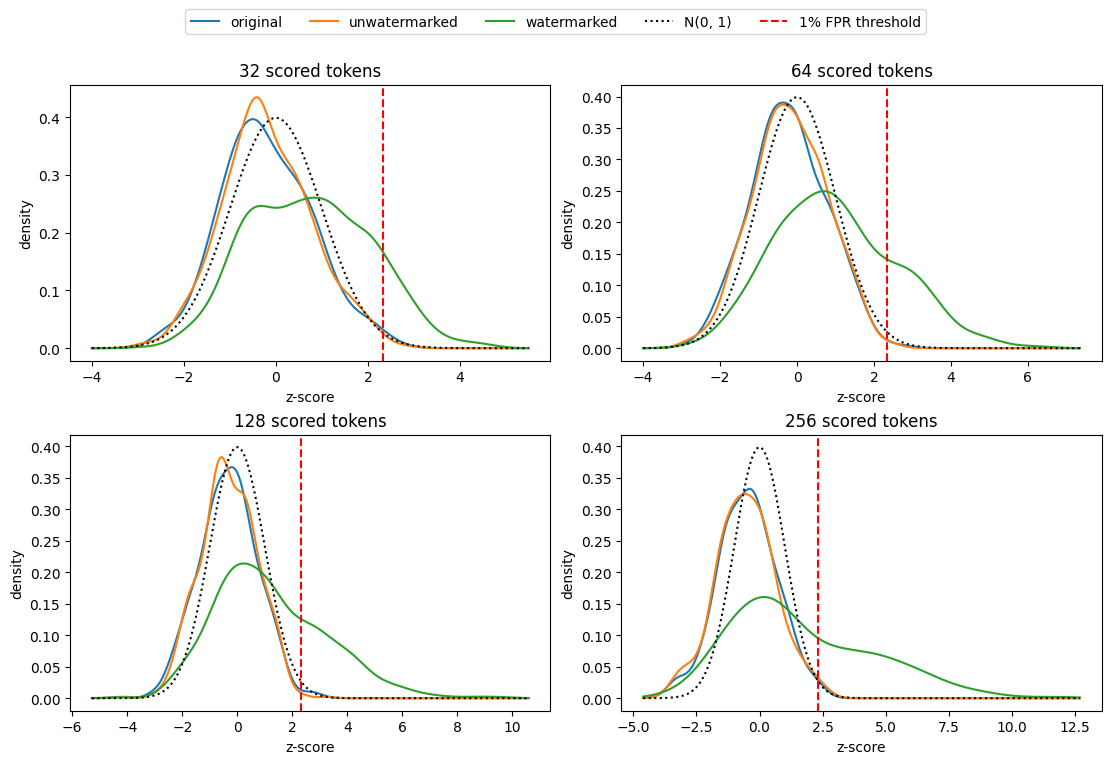

In [13]:
def prefix_z_scores(ids: list[int], source_id: int, mode: str) -> list[dict]:
    """计算同一文本在多个累计前缀长度下的KGW z-score，不作水印判定。"""
    rows = []
    for length in PREFIXES:
        # 第一个token只提供上下文，后面的length个token参与统计。
        if len(ids) >= length + CONTEXT_WIDTH:
            rows.append({"source_id": source_id, "mode": mode, "length": length,
                         **detector(ids[:length + CONTEXT_WIDTH])})
    return rows


# 将人类原文、无水印输出和有水印输出统一成待评分样本，然后统一计算z-score
samples = [(source.id, "original", tokenizer(source.text, add_special_tokens=False).input_ids)
           for source in sources.itertuples(index=False)]
samples += [(row["source_id"], "unwatermarked" if row["delta"] == 0 else "watermarked",
             row["token_ids"]) for row in valid_records]
z_score_rows = [score for source_id, mode, ids in samples
              for score in prefix_z_scores(ids, source_id, mode)]

z_scores = pd.DataFrame(z_score_rows)

# original和unwatermarked应接近N(0, 1)，watermarked的均值应随长度增长。
z_score_summary = (
    z_scores.groupby(["mode", "length"])["z"]
    .agg(samples="size", mean="mean", std="std")
    .reset_index()
)
display(z_score_summary.round(3))

# 展示累计前缀变长时的分布：无水印分布应近似稳定，
# 有水印分布则应逐渐向更大的z-score移动。红线为理论1% FPR阈值。
fig, axes = plt.subplots(2, 2, figsize=(11, 7), constrained_layout=True)
colors = {"original": "tab:blue", "unwatermarked": "tab:orange", "watermarked": "tab:green"}

for axis, length in zip(axes.flat, PREFIXES):
    part = z_scores[z_scores["length"] == length]
    x = np.linspace(min(-4, part["z"].min() - 1), max(4, part["z"].max() + 1), 300)
    for mode, color in colors.items():
        values = part.loc[part["mode"] == mode, "z"]
        if len(values) > 1 and values.std() > 0:
            axis.plot(x, gaussian_kde(values)(x), color=color, linewidth=1.5, label=mode)
    axis.plot(x, norm.pdf(x), "k:", label="N(0, 1)")
    axis.axvline(THEORETICAL_Z_THRESHOLD, color="red", linestyle="--", label="1% FPR threshold")
    axis.set(title=f"{length} scored tokens", xlabel="z-score", ylabel="density")

handles, labels = axes.flat[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", bbox_to_anchor=(0.5, 1.08), ncol=5)
plt.show()

In [14]:
# 每个长度使用全部可评分文本：original和unwatermarked为负类，watermarked为正类。
evaluation = []
for length, part in z_scores.groupby("length"):
    positive = part["mode"] == "watermarked"
    predicted = part["z"].map(lambda z: is_watermarked(z, THEORETICAL_Z_THRESHOLD))
    evaluation.append({
        "length": length,
        "neg_samples": (~positive).sum(),
        "pos_samples": positive.sum(),
        "ROC-AUC": roc_auc_score(positive, part["z"]),
        "Precision": precision_score(positive, predicted, zero_division=0),
        "Recall": recall_score(positive, predicted),
        "FPR": predicted[~positive].mean(),
    })

evaluation = pd.DataFrame(evaluation)
display(evaluation.round(3))

,length,neg_samples,pos_samples,ROC-AUC,Precision,Recall,FPR
0,32,1344,664,0.702,0.888,0.131,0.008
1,64,1337,651,0.728,0.977,0.194,0.002
2,128,1311,623,0.738,0.960,0.273,0.005
3,256,472,214,0.750,0.962,0.355,0.006
